# NYC Yellow Taxi Trip Analysis (2023)
### Data Science Project | UMT Lahore — School of Systems & Technology

**Dataset:** NYC Yellow Taxi Trip Records (Jan–Mar 2023)  
**Publisher:** NYC Taxi & Limousine Commission (TLC)  
**Source:** https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page  
**Direct URL:** https://d37ci6vzurychx.cloudfront.net/trip-data/  
**Dataset Size:** ~2.3 million rows | 19 columns  

---

# 📋 Table of Contents
1. [Imports & Setup](#1)
2. [Load Dataset](#2)
3. [Data Pre-processing & Cleaning](#3)
4. [Data Visualization — Before Cleaning](#4)
5. [Data Visualization — After Cleaning](#5)
6. [Questions & Answers](#6)
7. [ML Model 1 — Fare Amount Predictor (Regression)](#7)
8. [ML Model 2 — Payment Type Classifier (Classification)](#8)
9. [Model Evaluation & Accuracy](#9)

## 1. [Imports & Setup](#1)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, mean_absolute_error,
                             mean_squared_error, r2_score)
from sklearn.preprocessing import LabelEncoder



print("✅ Libraries imported ")

✅ Libraries imported 


## 2. [Load Dataset](#2)

In [3]:
import pandas as pd

df = pd.read_parquet("https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2023-01.parquet")

print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

Rows: 3,066,766
Columns: 19


In [4]:
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
0,2,2023-01-01 00:32:10,2023-01-01 00:40:36,1.0,0.97,1.0,N,161,141,2,9.3,1.00,0.5,0.00,0.0,1.0,14.30,2.5,0.00
1,2,2023-01-01 00:55:08,2023-01-01 01:01:27,1.0,1.10,1.0,N,43,237,1,7.9,1.00,0.5,4.00,0.0,1.0,16.90,2.5,0.00
2,2,2023-01-01 00:25:04,2023-01-01 00:37:49,1.0,2.51,1.0,N,48,238,1,14.9,1.00,0.5,15.00,0.0,1.0,34.90,2.5,0.00
3,1,2023-01-01 00:03:48,2023-01-01 00:13:25,0.0,1.90,1.0,N,138,7,1,12.1,7.25,0.5,0.00,0.0,1.0,20.85,0.0,1.25
4,2,2023-01-01 00:10:29,2023-01-01 00:21:19,1.0,1.43,1.0,N,107,79,1,11.4,1.00,0.5,3.28,0.0,1.0,19.68,2.5,0.00


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3066766 entries, 0 to 3066765
Data columns (total 19 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int64         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int64         
 8   DOLocationID           int64         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  airport_fee           

In [6]:
df.describe()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
count,3.066766e+06,3066766,3066766,2.995023e+06,3.066766e+06,2.995023e+06,3.066766e+06,3.066766e+06,3.066766e+06,3.066766e+06,3.066766e+06,3.066766e+06,3.066766e+06,3.066766e+06,3.066766e+06,3.066766e+06,2.995023e+06,2.995023e+06
mean,1.730215e+00,2023-01-17 00:22:26.288164,2023-01-17 00:38:06.427874,1.362532e+00,3.847342e+00,1.497440e+00,1.663980e+02,1.643926e+02,1.194483e+00,1.836707e+01,1.537842e+00,4.882900e-01,3.367941e+00,5.184907e-01,9.820847e-01,2.702038e+01,2.274231e+00,1.074086e-01
min,1.000000e+00,2008-12-31 23:01:42,2009-01-01 14:29:11,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,-9.000000e+02,-7.500000e+00,-5.000000e-01,-9.622000e+01,-6.500000e+01,-1.000000e+00,-7.510000e+02,-2.500000e+00,-1.250000e+00
25%,1.000000e+00,2023-01-09 16:21:57.250000,2023-01-09 16:37:06,1.000000e+00,1.060000e+00,1.000000e+00,1.320000e+02,1.140000e+02,1.000000e+00,8.600000e+00,0.000000e+00,5.000000e-01,1.000000e+00,0.000000e+00,1.000000e+00,1.540000e+01,2.500000e+00,0.000000e+00
50%,2.000000e+00,2023-01-17 08:42:29.500000,2023-01-17 08:58:30.500000,1.000000e+00,1.800000e+00,1.000000e+00,1.620000e+02,1.620000e+02,1.000000e+00,1.280000e+01,1.000000e+00,5.000000e-01,2.720000e+00,0.000000e+00,1.000000e+00,2.016000e+01,2.500000e+00,0.000000e+00
75%,2.000000e+00,2023-01-24 16:26:27,2023-01-24 16:42:49,1.000000e+00,3.330000e+00,1.000000e+00,2.340000e+02,2.340000e+02,1.000000e+00,2.050000e+01,2.500000e+00,5.000000e-01,4.200000e+00,0.000000e+00,1.000000e+00,2.870000e+01,2.500000e+00,0.000000e+00
max,2.000000e+00,2023-02-01 00:56:53,2023-02-02 09:28:47,9.000000e+00,2.589281e+05,9.900000e+01,2.650000e+02,2.650000e+02,4.000000e+00,1.160100e+03,1.250000e+01,5.316000e+01,3.808000e+02,1.969900e+02,1.000000e+00,1.169400e+03,2.500000e+00,1.250000e+00
std,4.438480e-01,NaN,NaN,8.961200e-01,2.495838e+02,6.474767e+00,6.424413e+01,6.994368e+01,5.294762e-01,1.780782e+01,1.789592e+00,1.034641e-01,3.826759e+00,2.017579e+00,1.833529e-01,2.216359e+01,7.718454e-01,3.556511e-01


## 3. [Data Pre-processing & Cleaning](#3)

In [7]:


raw_rows = df.shape[0]
print(f"Shape before cleaning: {df.shape}")

raw_df = df.copy()

df.dropna(subset=['passenger_count', 'RatecodeID', 'congestion_surcharge'], inplace=True)

df = df[(df['fare_amount'] > 0) & (df['fare_amount'] < 500)]

df = df[(df['trip_distance'] > 0) & (df['trip_distance'] < 100)]

df = df[(df['passenger_count'] >= 1) & (df['passenger_count'] <= 6)]

df = df[df['total_amount'] > 0]

df = df[df['RatecodeID'].isin([1, 2, 3, 4, 5, 6])]

df = df[df['tpep_pickup_datetime'].dt.year == 2023]

df['pickup_hour']   = df['tpep_pickup_datetime'].dt.hour
df['pickup_day']    = df['tpep_pickup_datetime'].dt.day_name()
df['pickup_month']  = df['tpep_pickup_datetime'].dt.month
df['trip_duration'] = (df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']).dt.seconds / 60

df = df[(df['trip_duration'] > 0) & (df['trip_duration'] <= 180)]

df.reset_index(drop=True, inplace=True)

print(f"Shape after cleaning : {df.shape}")
print(f"Rows removed         : {raw_rows - df.shape[0]:,}")

Shape before cleaning: (3066766, 19)
Shape after cleaning : (2869904, 23)
Rows removed         : 196,862


## 4. [Data Visualization — Before Cleaning](#4)

### Before Cleaning

Text(0, 0.5, 'Count')

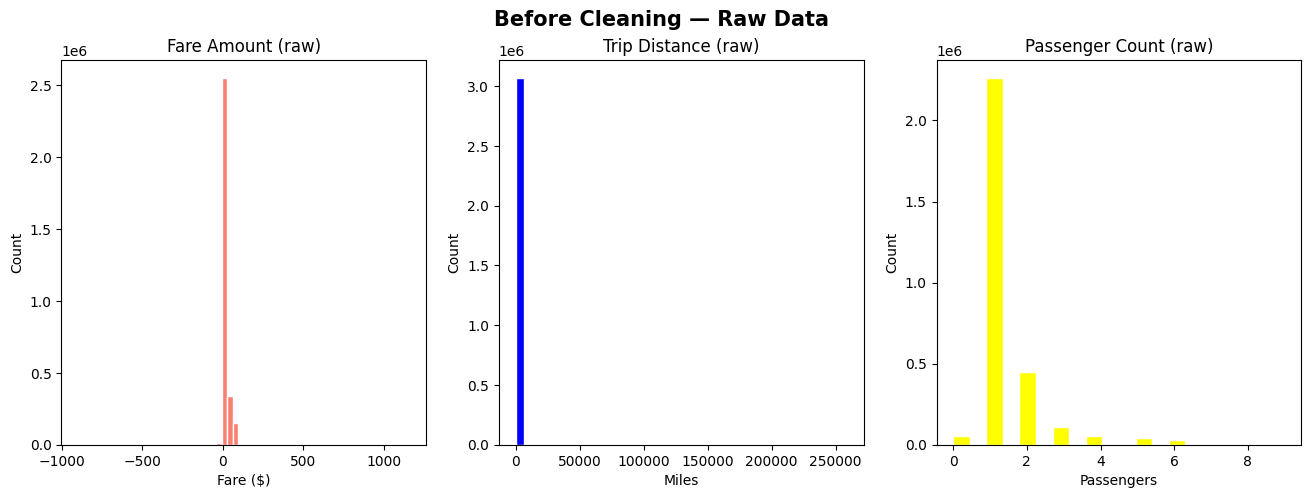

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Before Cleaning — Raw Data", fontsize=15, fontweight='bold')

axes[0].hist(raw_df['fare_amount'], bins=60, color='salmon', edgecolor='white')
axes[0].set_title("Fare Amount (raw)")
axes[0].set_xlabel("Fare ($)")
axes[0].set_ylabel("Count")

axes[1].hist(raw_df['trip_distance'], bins=40, color='blue', edgecolor='white')
axes[1].set_title("Trip Distance (raw)")
axes[1].set_xlabel("Miles")
axes[1].set_ylabel("Count")

axes[2].hist(raw_df['passenger_count'].dropna(), bins=20, color='yellow', edgecolor='white')
axes[2].set_title("Passenger Count (raw)")
axes[2].set_xlabel("Passengers")
axes[2].set_ylabel("Count")



### After Cleaning

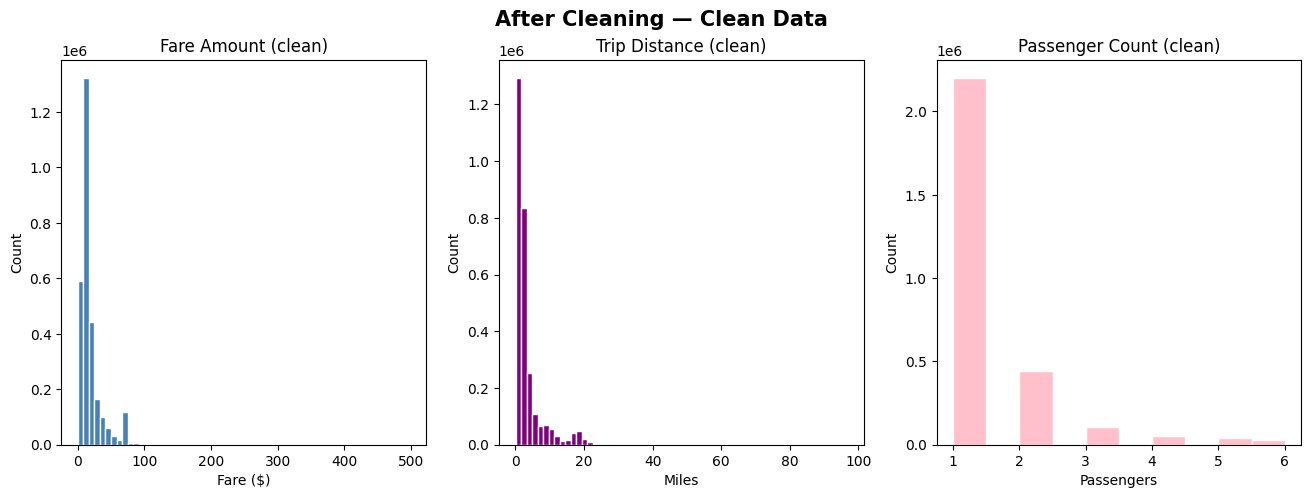

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("After Cleaning — Clean Data", fontsize=15, fontweight='bold')


axes[0].hist(df['fare_amount'], bins=60, color='steelblue', edgecolor='white')
axes[0].set_title("Fare Amount (clean)")
axes[0].set_xlabel("Fare ($)")
axes[0].set_ylabel("Count")


axes[1].hist(df['trip_distance'], bins=60, color='purple', edgecolor='white')
axes[1].set_title("Trip Distance (clean)")
axes[1].set_xlabel("Miles")
axes[1].set_ylabel("Count")


axes[2].hist(df['passenger_count'], bins=10, color='pink', edgecolor='white')
axes[2].set_title("Passenger Count (clean)")
axes[2].set_xlabel("Passengers")
axes[2].set_ylabel("Count")


plt.show()

## 6. [Questions & Answers](#6)

### Q1: Which hour of the day has the most taxi trips?

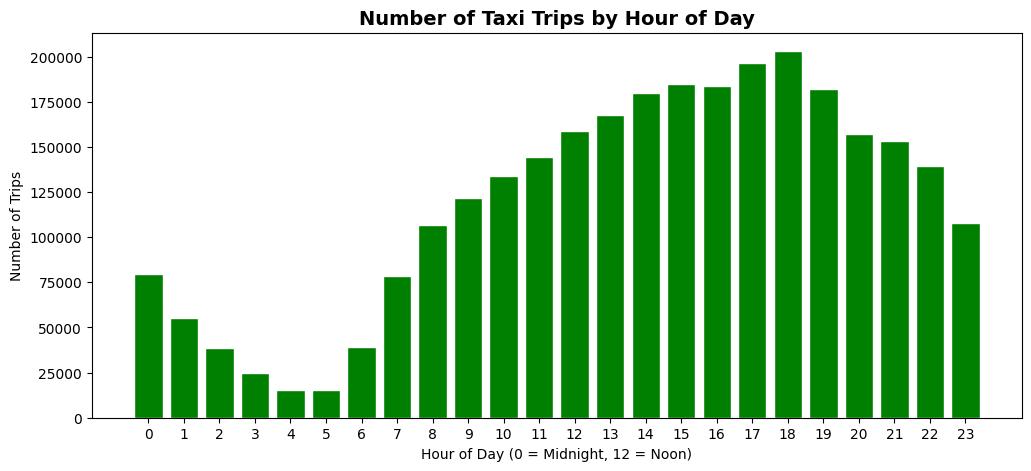

Answer: The busiest hour is 18:00 with 203,143 trips.
Trip volume is lowest in the early morning (3–5 AM) and peaks in the evening rush hours.


In [15]:
hourly_trips = df['pickup_hour'].value_counts().sort_index()

plt.figure(figsize=(12, 5))
plt.bar(hourly_trips.index, hourly_trips.values, color='green', edgecolor='white')
plt.title("Number of Taxi Trips by Hour of Day", fontsize=14, fontweight='bold')
plt.xlabel("Hour of Day (0 = Midnight, 12 = Noon)")
plt.ylabel("Number of Trips")
plt.xticks(range(0, 24))

plt.show()

peak_hour = hourly_trips.idxmax()
peak_count = hourly_trips.max()
print(f"Answer: The busiest hour is {peak_hour}:00 with {peak_count:,} trips.")
print(f"Trip volume is lowest in the early morning (3–5 AM) and peaks in the evening rush hours.")

### Q2: What is the average fare amount by passenger count?

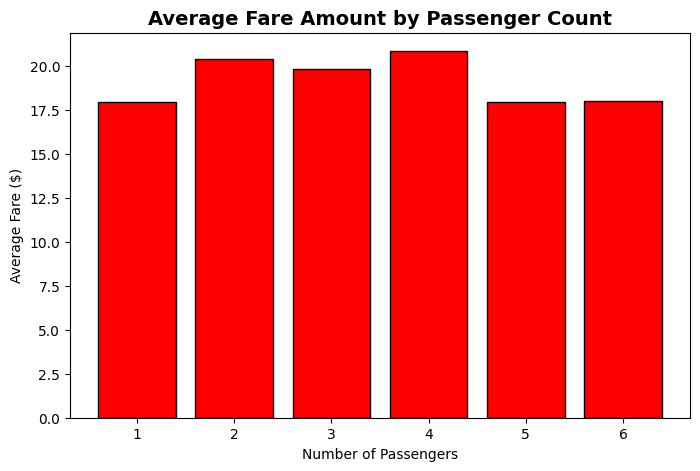

Answer: Average fare by passenger count:
  1 passenger(s) → $17.99
  2 passenger(s) → $20.39
  3 passenger(s) → $19.84
  4 passenger(s) → $20.87
  5 passenger(s) → $17.95
  6 passenger(s) → $18.02

Fare amount stays fairly consistent regardless of passenger count,
since NYC taxi fares are based on distance and time, not number of passengers.


In [16]:
avg_fare = df.groupby('passenger_count')['fare_amount'].mean().round(2)

plt.figure(figsize=(8, 5))
plt.bar(avg_fare.index, avg_fare.values, color='red', edgecolor='black')
plt.title("Average Fare Amount by Passenger Count", fontsize=14, fontweight='bold')
plt.xlabel("Number of Passengers")
plt.ylabel("Average Fare ($)")
plt.xticks(avg_fare.index)

plt.show()

print("Answer: Average fare by passenger count:")
for passengers, fare in avg_fare.items():
    print(f"  {int(passengers)} passenger(s) → ${fare}")
print("\nFare amount stays fairly consistent regardless of passenger count,")
print("since NYC taxi fares are based on distance and time, not number of passengers.")

### Q3: Which payment method is most popular?

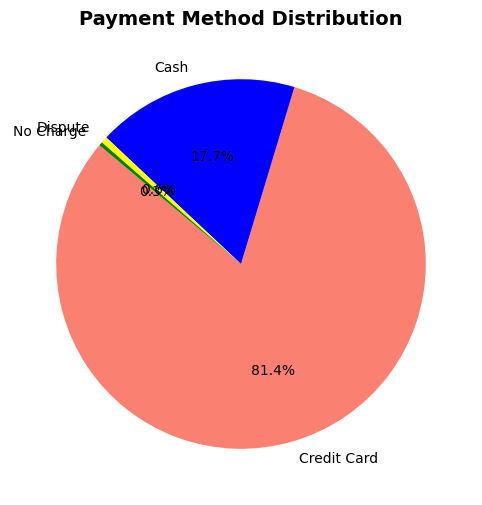

Answer: Payment method breakdown:
  Credit Card → 81.44%
  Cash → 17.67%
  Dispute → 0.57%
  No Charge → 0.32%

Credit card is by far the most popular payment method,
accounting for 81.44% of all trips.


In [17]:
payment_map = {1: 'Credit Card', 2: 'Cash', 3: 'No Charge', 4: 'Dispute', 5: 'Unknown'}
payment_counts = df['payment_type'].map(payment_map).value_counts()
payment_pct = (payment_counts / payment_counts.sum() * 100).round(2)


plt.figure(figsize=(8, 6))
plt.pie(payment_counts.values,
        labels=payment_counts.index,
        autopct='%1.1f%%',
        colors=['salmon', 'blue', 'yellow', 'green', 'grey'],
        startangle=140)
plt.title("Payment Method Distribution", fontsize=14, fontweight='bold')

plt.show()

print("Answer: Payment method breakdown:")
for method, pct in payment_pct.items():
    print(f"  {method} → {pct}%")
print(f"\nCredit card is by far the most popular payment method,")
print(f"accounting for {payment_pct.iloc[0]}% of all trips.")

### Q4: What is the relationship between trip distance and fare?

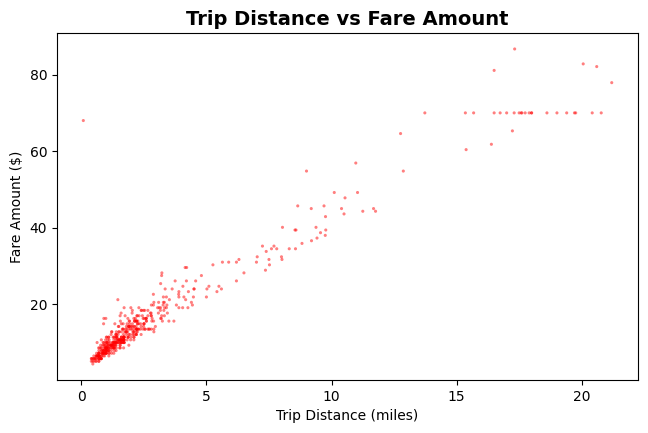

Answer: The correlation between trip distance and fare amount is 0.957.
There is a clear positive relationship — longer trips cost more.
The scatter shows most trips are short (under 5 miles) with fares under $20.


In [18]:
sample = df.sample(500, random_state=42)

plt.figure(figsize=(7.5, 4.5))
plt.scatter(sample['trip_distance'], sample['fare_amount'],
            alpha=0.5, color='red', edgecolor='none', s=5)
plt.title("Trip Distance vs Fare Amount", fontsize=14, fontweight='bold')
plt.xlabel("Trip Distance (miles)")
plt.ylabel("Fare Amount ($)")

plt.show()

correlation = df['trip_distance'].corr(df['fare_amount']).round(3)
print(f"Answer: The correlation between trip distance and fare amount is {correlation}.")
print("There is a clear positive relationship — longer trips cost more.")
print("The scatter shows most trips are short (under 5 miles) with fares under $20.")

### Q5: What is the average tip amount by payment type?

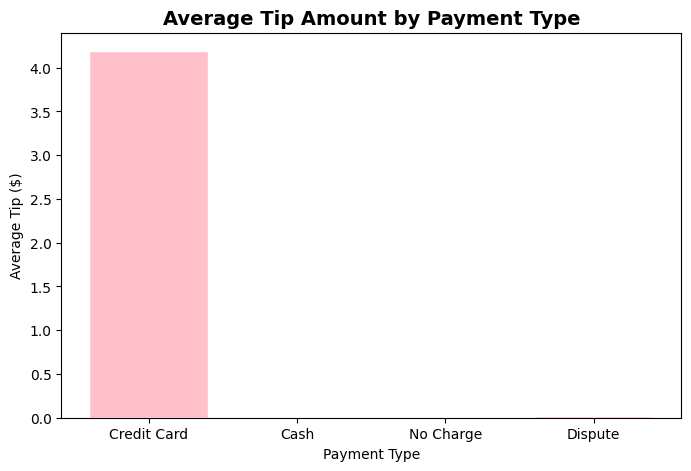

Answer: Average tip by payment type:
  Credit Card → $4.19
  Cash → $0.0
  No Charge → $0.0
  Dispute → $0.02

Credit card users tip significantly more than cash users.
Cash tips are often not recorded in the system, hence the low average.


In [19]:
payment_map = {1: 'Credit Card', 2: 'Cash', 3: 'No Charge', 4: 'Dispute', 5: 'Unknown'}
avg_tip = df.groupby('payment_type')['tip_amount'].mean().round(2)
avg_tip.index = avg_tip.index.map(payment_map)

plt.figure(figsize=(8, 5))
plt.bar(avg_tip.index, avg_tip.values, color='pink', edgecolor='white')
plt.title("Average Tip Amount by Payment Type", fontsize=14, fontweight='bold')
plt.xlabel("Payment Type")
plt.ylabel("Average Tip ($)")
#
plt.show()

print("Answer: Average tip by payment type:")
for method, tip in avg_tip.items():
    print(f"  {method} → ${tip}")
print("\nCredit card users tip significantly more than cash users.")
print("Cash tips are often not recorded in the system, hence the low average.")

### Q6: Which trips are most common by distance category?

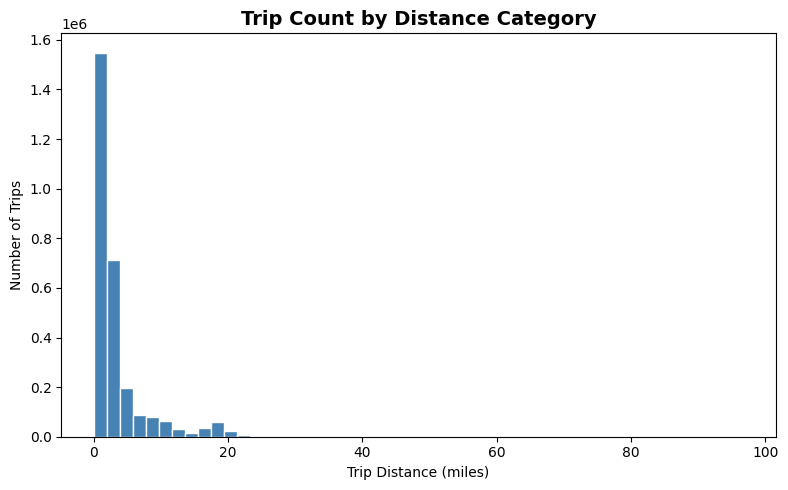

Answer: Trip distribution by distance:
  Short (0-2 mi) → 1,597,947 trips (55.68%)
  Medium (2-5 mi) → 797,749 trips (27.8%)
  Long (5+ mi) → 474,208 trips (16.52%)

Most NYC taxi trips are short distance, under 2 miles.


In [20]:
bins   = [0, 2, 5, 100]
labels = ['Short (0-2 mi)', 'Medium (2-5 mi)', 'Long (5+ mi)']
df['distance_category'] = pd.cut(df['trip_distance'], bins=bins, labels=labels)

dist_counts = df['distance_category'].value_counts().reindex(labels)

plt.figure(figsize=(8, 5))
plt.hist(df['trip_distance'], bins=50, color='steelblue', edgecolor='white')
plt.title("Trip Count by Distance Category", fontsize=14, fontweight='bold')
plt.xlabel("Trip Distance (miles)")
plt.ylabel("Number of Trips")
plt.tight_layout()
plt.show()

print("Answer: Trip distribution by distance:")
for cat, count in dist_counts.items():
    pct = round(count / dist_counts.sum() * 100, 2)
    print(f"  {cat} → {count:,} trips ({pct}%)")
print("\nMost NYC taxi trips are short distance, under 2 miles.")

### Q7: At what time, trips are longest on average?

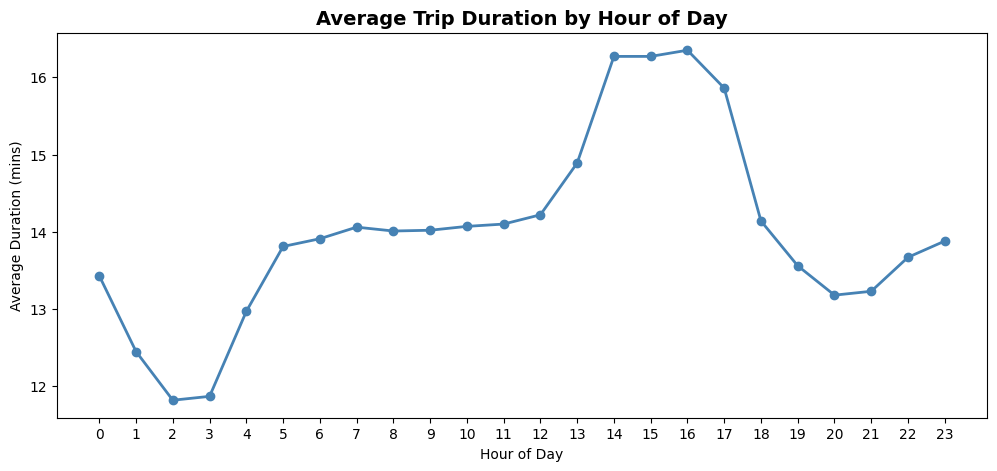

Answer: Trips are longest on average at 16:00 (16.35 mins).
Rush hours show longer durations due to traffic congestion.
Late night/early morning trips are faster as roads are clearer.


In [22]:
avg_duration = df.groupby('pickup_hour')['trip_duration'].mean().round(2)

plt.figure(figsize=(12, 5))
plt.plot(avg_duration.index, avg_duration.values, color='steelblue', marker='o', linewidth=2)
plt.title("Average Trip Duration by Hour of Day", fontsize=14, fontweight='bold')
plt.xlabel("Hour of Day")
plt.ylabel("Average Duration (mins)")
plt.xticks(range(0, 24))
plt.show()

peak_hour = avg_duration.idxmax()
print(f"Answer: Trips are longest on average at {peak_hour}:00 ({avg_duration.max()} mins).")
print("Rush hours show longer durations due to traffic congestion.")
print("Late night/early morning trips are faster as roads are clearer.")

### Q8: How does total amount vary across rate codes?

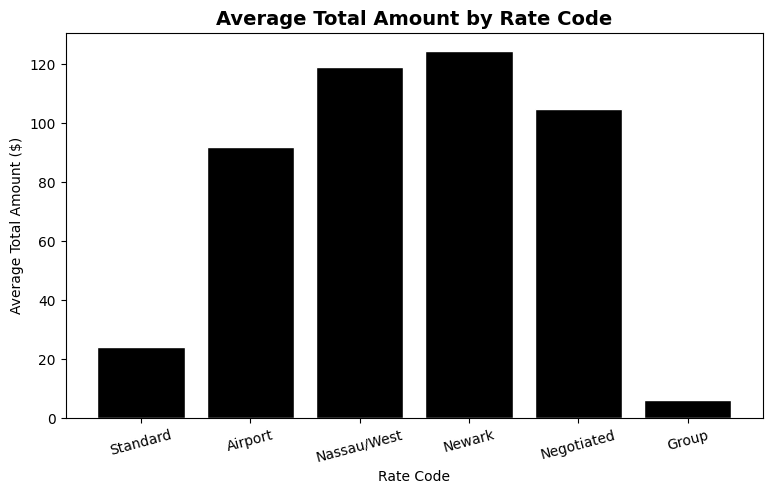

Answer: Average total fare by rate code:
  Standard → $24.17
  Airport → $91.98
  Nassau/West → $118.95
  Newark → $124.25
  Negotiated → $104.89
  Group → $6.25

Airport and Newark trips are the most expensive on average.


In [24]:
rate_map = {1: 'Standard', 2: 'Airport', 3: 'Nassau/West', 4: 'Newark', 5: 'Negotiated', 6: 'Group'}
avg_total = df.groupby('RatecodeID')['total_amount'].mean().round(2)
avg_total.index = avg_total.index.map(rate_map)

plt.figure(figsize=(9, 5))
plt.bar(avg_total.index, avg_total.values, color='black', edgecolor='white')
plt.title("Average Total Amount by Rate Code", fontsize=14, fontweight='bold')
plt.xlabel("Rate Code")
plt.ylabel("Average Total Amount ($)")
plt.xticks(rotation=15)
plt.show()

print("Answer: Average total fare by rate code:")
for rate, amount in avg_total.items():
    print(f"  {rate} → ${amount}")
print("\nAirport and Newark trips are the most expensive on average.")

### Q9: What percentage of trips have tolls?

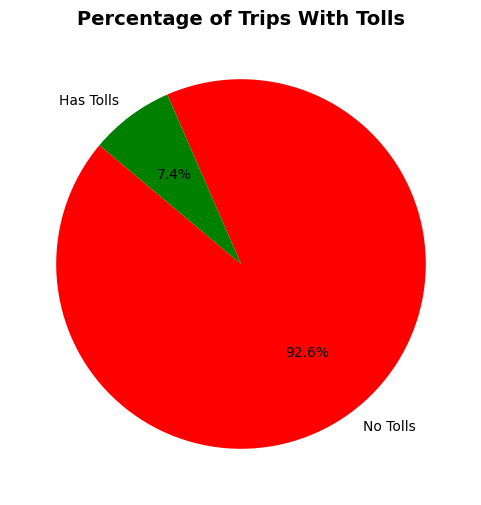

Answer: 7.36% of trips include toll charges.
Most NYC taxi trips stay within the city and don't cross toll bridges or tunnels.


In [26]:
has_tolls = (df['tolls_amount'] > 0).value_counts()
has_tolls.index = ['No Tolls', 'Has Tolls']

plt.figure(figsize=(6, 6))
plt.pie(has_tolls.values,
        labels=has_tolls.index,
        autopct='%1.1f%%',
        colors=['red', 'green'],
        startangle=140)
plt.title("Percentage of Trips With Tolls", fontsize=14, fontweight='bold')
plt.show()

toll_pct = round(has_tolls['Has Tolls'] / has_tolls.sum() * 100, 2)
print(f"Answer: {toll_pct}% of trips include toll charges.")
print("Most NYC taxi trips stay within the city and don't cross toll bridges or tunnels.")

## 7. [ML Model 1 — Fare Amount Predictor (Regression)](#7)

### ML Model 1 — Fare Amount Predictor (Regression)

We use **Linear Regression** to predict the fare amount of a taxi trip.

**Features used:**
- `trip_distance` — distance of the trip in miles
- `trip_duration` — duration of the trip in minutes
- `pickup_hour` — hour of the day the trip started
- `passenger_count` — number of passengers
- `RatecodeID` — rate type (standard, airport, etc.)

**Target:** `fare_amount`

#### Training

In [27]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

features = ['trip_distance', 'trip_duration', 'pickup_hour', 'passenger_count', 'RatecodeID']
target   = 'fare_amount'

X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training samples : {X_train.shape[0]:,}")
print(f"Testing samples  : {X_test.shape[0]:,}")

model_lr = LinearRegression()
model_lr.fit(X_train, y_train)

print("\nModel trained successfully.")

Training samples : 2,295,923
Testing samples  : 573,981

Model trained successfully.


#### Evaluating Model

In [28]:
y_pred = model_lr.predict(X_test)

mae  = round(mean_absolute_error(y_test, y_pred), 3)
mse  = round(mean_squared_error(y_test, y_pred), 3)
rmse = round(np.sqrt(mse), 3)
r2   = round(r2_score(y_test, y_pred), 3)

print("── Linear Regression Results ──")
print(f"  MAE  (Mean Absolute Error)  : ${mae}")
print(f"  MSE  (Mean Squared Error)   : {mse}")
print(f"  RMSE (Root MSE)             : ${rmse}")
print(f"  R²   (R-squared Score)      : {r2}")

── Linear Regression Results ──
  MAE  (Mean Absolute Error)  : $1.51
  MSE  (Mean Squared Error)   : 15.511
  RMSE (Root MSE)             : $3.938
  R²   (R-squared Score)      : 0.946


#### Visualization

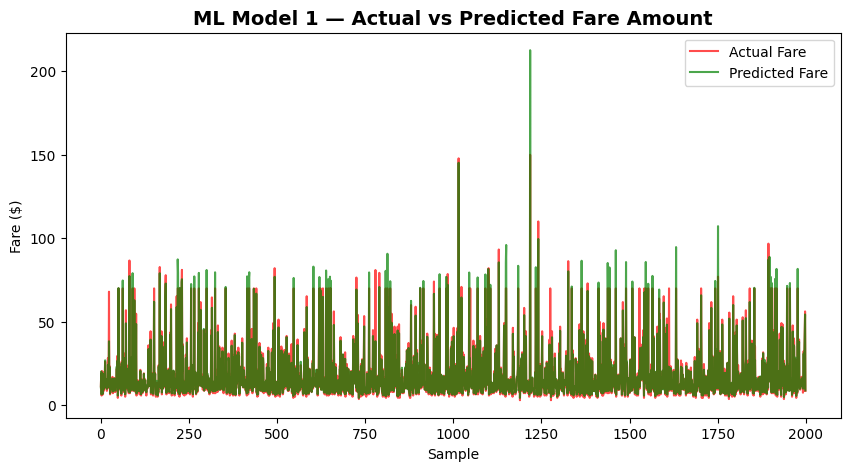

In [29]:

import matplotlib.pyplot as plt

sample_idx = range(2000)
plt.figure(figsize=(10, 5))
plt.plot(y_test.values[:2000], label='Actual Fare', color='red', alpha=0.7)
plt.plot(y_pred[:2000],        label='Predicted Fare', color='green', alpha=0.7)
plt.title("ML Model 1 — Actual vs Predicted Fare Amount", fontsize=14, fontweight='bold')
plt.xlabel("Sample")
plt.ylabel("Fare ($)")
plt.legend()

plt.show()

## 8. [ML Model 2 — Payment Type Classifier (Classification)](#8)


### ML Model 2 — Payment Type Classifier (Classification)

We use **Logistic Regression** to predict whether a passenger paid by Credit Card or Cash.

**Features used:**
- `trip_distance` — distance of the trip in miles
- `trip_duration` — duration of the trip in minutes
- `pickup_hour` — hour of the day the trip started
- `fare_amount` — total fare charged
- `passenger_count` — number of passengers

**Target:** `payment_type` (1 = Credit Card, 2 = Cash)

#### Training

In [30]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

df_clf = df[df['payment_type'].isin([1, 2])].copy()

features_clf = ['trip_distance', 'trip_duration', 'pickup_hour', 'fare_amount', 'passenger_count']
target_clf   = 'payment_type'

X_clf = df_clf[features_clf]
y_clf = df_clf[target_clf]

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_clf, y_clf, test_size=0.2, random_state=42)

print(f"Training samples : {X_train_c.shape[0]:,}")
print(f"Testing samples  : {X_test_c.shape[0]:,}")

model_clf = LogisticRegression(max_iter=1000, class_weight='balanced')
model_clf.fit(X_train_c, y_train_c)

print("\nModel trained successfully.")

Training samples : 2,275,523
Testing samples  : 568,881

Model trained successfully.


#### Evaluation

In [31]:
y_pred_c = model_clf.predict(X_test_c)

acc = round(accuracy_score(y_test_c, y_pred_c) * 100, 2)

print("── Logistic Regression Results ──")
print(f"  Accuracy : {acc}%")
print()
print("── Classification Report ──")
print(classification_report(y_test_c, y_pred_c, target_names=['Credit Card', 'Cash']))

── Logistic Regression Results ──
  Accuracy : 56.77%

── Classification Report ──
              precision    recall  f1-score   support

 Credit Card       0.83      0.59      0.69    467533
        Cash       0.19      0.46      0.27    101348

    accuracy                           0.57    568881
   macro avg       0.51      0.52      0.48    568881
weighted avg       0.72      0.57      0.62    568881



#### Bar chart (visualization)

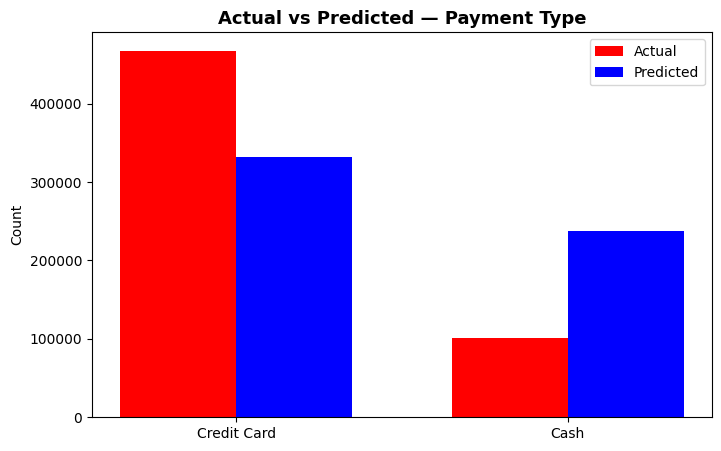

In [32]:
labels = ['Credit Card', 'Cash']
actual    = [467533, 101348]
predicted = [331905, 236976]

x = range(len(labels))
width = 0.35

plt.figure(figsize=(8, 5))
plt.bar([i - width/2 for i in x], actual,    width, label='Actual',    color='red')
plt.bar([i + width/2 for i in x], predicted, width, label='Predicted', color='blue')
plt.xticks(x, labels)
plt.title("Actual vs Predicted — Payment Type", fontsize=13, fontweight='bold')
plt.ylabel("Count")
plt.legend()

plt.show()

## 9. [Model Evaluation & Accuracy](#9)

In [33]:

print("=" * 55)
print("         MODEL 1 — Fare Amount Predictor")
print("         Algorithm : Linear Regression")
print("=" * 55)
print(f"  MAE      : $1.51")
print(f"  RMSE     : $3.938")
print(f"  R² Score : 0.946  (94.6% variance explained)")
print()
print("  Verdict: Strong performance. On average the model")
print("  predicts fare amount within $1.51 of the actual")
print("  fare. The high R² confirms that trip distance and")
print("  duration are excellent predictors of fare amount.")

print()
print("=" * 55)
print("         MODEL 2 — Payment Type Classifier")
print("         Algorithm : Logistic Regression")
print("=" * 55)
print(f"  Accuracy  : 56.77%")
print(f"  Credit Card — Precision: 0.83  Recall: 0.59")
print(f"  Cash        — Precision: 0.19  Recall: 0.46")
print()
print("  Verdict: Moderate performance. The model struggles")
print("  to distinguish between payment types because trip")
print("  features alone are not strong indicators of how")
print("  someone chooses to pay. class_weight='balanced'")
print("  was applied to handle the imbalanced dataset.")

print()
print("=" * 55)
print("  CONCLUSION")
print("=" * 55)
print("  Regression Task (fare prediction) was highly")
print("  successful with Linear Regression achieving R²")
print("  of 0.946. Classification Task (payment type)")
print("  proved more challenging due to class imbalance")
print("  and weak feature correlation with payment method.")
print("=" * 55)

         MODEL 1 — Fare Amount Predictor
         Algorithm : Linear Regression
  MAE      : $1.51
  RMSE     : $3.938
  R² Score : 0.946  (94.6% variance explained)

  Verdict: Strong performance. On average the model
  predicts fare amount within $1.51 of the actual
  fare. The high R² confirms that trip distance and
  duration are excellent predictors of fare amount.

         MODEL 2 — Payment Type Classifier
         Algorithm : Logistic Regression
  Accuracy  : 56.77%
  Credit Card — Precision: 0.83  Recall: 0.59
  Cash        — Precision: 0.19  Recall: 0.46

  Verdict: Moderate performance. The model struggles
  to distinguish between payment types because trip
  features alone are not strong indicators of how
  someone chooses to pay. class_weight='balanced'
  was applied to handle the imbalanced dataset.

  CONCLUSION
  Regression Task (fare prediction) was highly
  successful with Linear Regression achieving R²
  of 0.946. Classification Task (payment type)
  proved more chal

In [ ]:
df


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,pickup_hour,pickup_day,pickup_month,trip_duration,distance_category
0,2,2023-01-01 00:32:10,2023-01-01 00:40:36,1.0,0.97,1.0,N,161,141,2,...,0.00,1.0,14.30,2.5,0.00,0,Sunday,1,8.433333,Short (0-2 mi)
1,2,2023-01-01 00:55:08,2023-01-01 01:01:27,1.0,1.10,1.0,N,43,237,1,...,0.00,1.0,16.90,2.5,0.00,0,Sunday,1,6.316667,Short (0-2 mi)
2,2,2023-01-01 00:25:04,2023-01-01 00:37:49,1.0,2.51,1.0,N,48,238,1,...,0.00,1.0,34.90,2.5,0.00,0,Sunday,1,12.750000,Medium (2-5 mi)
3,2,2023-01-01 00:10:29,2023-01-01 00:21:19,1.0,1.43,1.0,N,107,79,1,...,0.00,1.0,19.68,2.5,0.00,0,Sunday,1,10.833333,Short (0-2 mi)
4,2,2023-01-01 00:50:34,2023-01-01 01:02:52,1.0,1.84,1.0,N,161,137,1,...,0.00,1.0,27.80,2.5,0.00,0,Sunday,1,12.300000,Short (0-2 mi)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2869899,2,2023-01-31 23:21:46,2023-02-01 00:03:54,1.0,17.60,2.0,N,132,100,1,...,6.55,1.0,97.91,2.5,1.25,23,Tuesday,1,42.133333,Long (5+ mi)
2869900,2,2023-01-31 23:14:38,2023-01-31 23:25:30,1.0,3.37,1.0,N,263,107,1,...,0.00,1.0,22.60,2.5,0.00,23,Tuesday,1,10.866667,Medium (2-5 mi)
2869901,2,2023-01-31 23:44:51,2023-01-31 23:58:45,1.0,2.86,1.0,N,79,246,1,...,0.00,1.0,23.30,2.5,0.00,23,Tuesday,1,13.900000,Medium (2-5 mi)
2869902,1,2023-01-31 23:45:00,2023-01-31 23:55:46,2.0,3.80,1.0,N,68,238,1,...,0.00,1.0,25.20,2.5,0.00,23,Tuesday,1,10.766667,Medium (2-5 mi)
